# Binding Energy

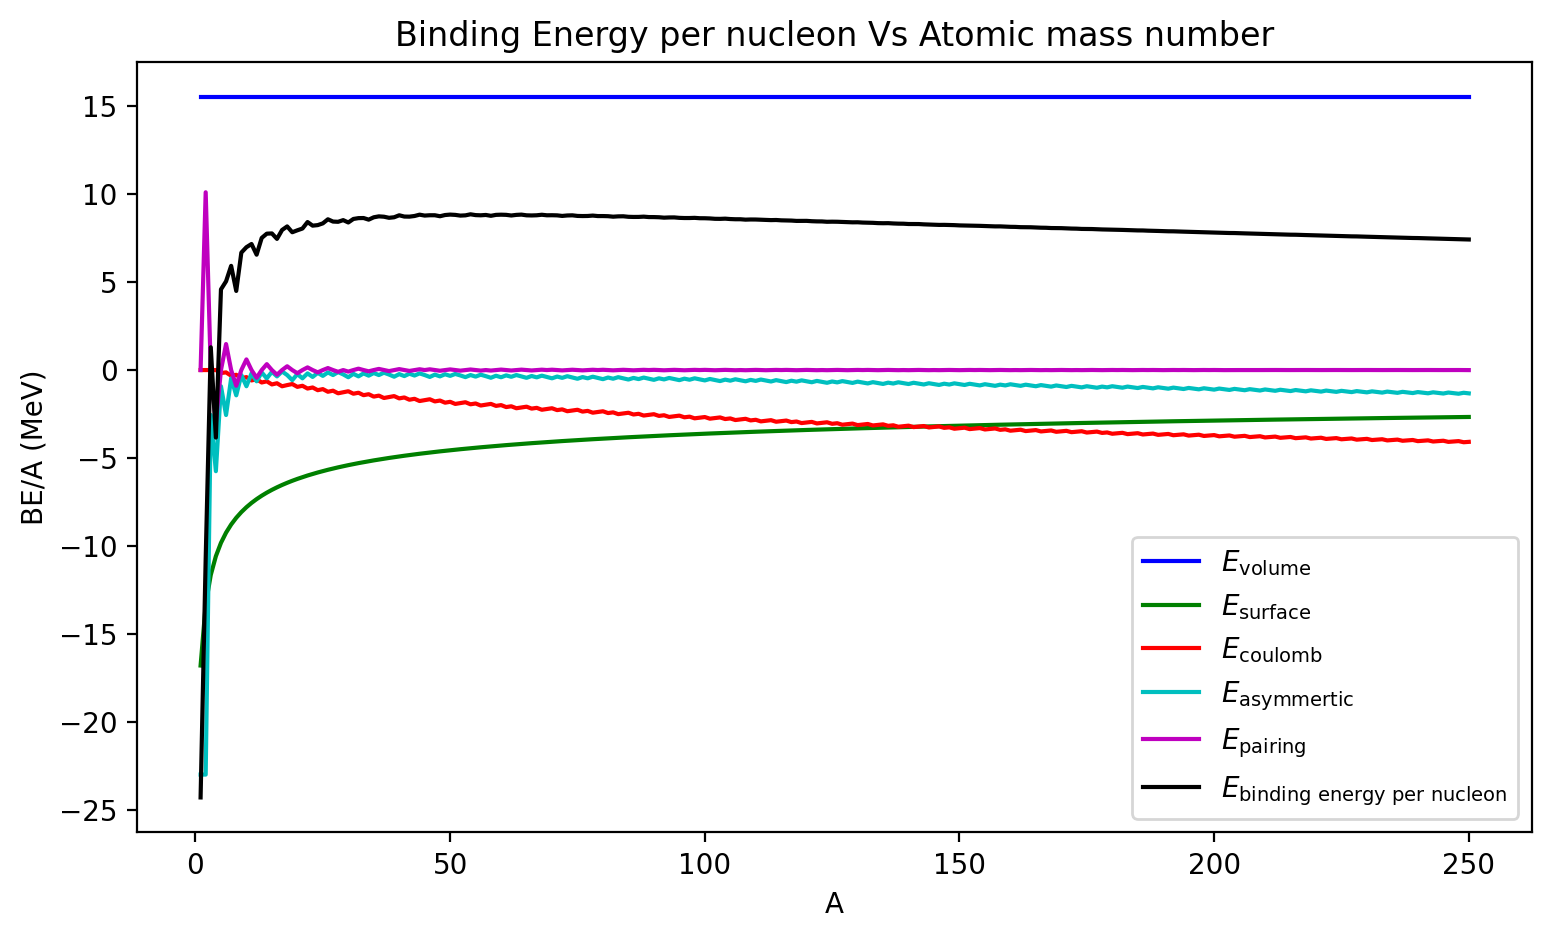

In [ ]:
# Graph of Binding Energy per nucleon Vs Atomic mass number

# Importing libraries
import matplotlib.pyplot as plt
import numpy as np

# Defining initial parameters
a_v = 15.5
a_s = 16.8
a_c = 0.72
a_asym = 23

# Creating Empty list for all the variables
N_list = []
Z_list = []
B_list = []
A_list = []
E_vol_list = []
E_surf_list = []
E_coulomb_list = []
E_asym_list = []
E_pair_list = []


# Defining the Binding Energy Function
def BE(A):

  # Finding Z_min for each A
  Z_min = A/2/(1+(1/4)*A**(2/3)*a_c/a_asym)
  Z = int(Z_min)
  Z_list.append(Z)

  # Similarly finding N from A and Z
  N = A - Z
  N_list.append(N)

  # Conditions on a_pair
  if Z%2==0 and N%2==0:
    a_p = 34
  elif Z%2==0 and N%2!=0:
    a_p = 0
  elif Z%2!=0 and N%2==0:
    a_p = 0
  elif Z%2!=0 and N%2!=0:
    a_p = -34

  # Mentioning all the Energy terms in Binding Energy Formula
  E_vol = a_v*A
  E_surf = a_s*A**(2/3)
  E_coulomb = a_c*Z*(Z-1)/(A**(1/3))
  E_asym = a_asym*(A-2*Z)**2/A
  E_pair = a_p/A**(3/4)

  # Binding Energy Formula
  be = E_vol - E_surf - E_coulomb - E_asym + E_pair

  # Attaching all the Energy variables to their corresponding list
  E_vol_list.append(E_vol/A)
  E_surf_list.append(-E_surf/A)
  E_coulomb_list.append(-E_coulomb/A)
  E_asym_list.append(-E_asym/A)
  E_pair_list.append(E_pair/A)

  # Returning the value be/A on call of the Binding Energy Function
  return be/A

# Iterating A from 1 to 250
for A in range(1,251):
  B_list.append(BE(A))
  A_list.append(A)

# # Printing Values for verification
# print(len(A_list),A_list)
# print(len(Z_list),Z_list)
# print(len(N_list),N_list)
# print(len(B_list),B_list)

# Plotting the Graph
plt.figure(figsize=(9, 5), dpi=200)
plt.title("Binding Energy per nucleon Vs Atomic mass number")
plt.plot(A_list,E_vol_list, color='b', label=r'$E_{\mathrm{volume}}$')
plt.plot(A_list,E_surf_list, color='g', label=r'$E_{\mathrm{surface}}$')
plt.plot(A_list,E_coulomb_list,  color='r', label=r'$E_{\mathrm{coulomb}}$')
plt.plot(A_list,E_asym_list, color='c', label=r'$E_{\mathrm{asymmertic}}$')
plt.plot(A_list,E_pair_list,  color='m',  label=r'$E_{\mathrm{pairing}}$')
plt.plot(A_list,B_list,  color='k', label=r'$E_{\mathrm{binding\ energy\ per\ nucleon}}$')

plt.xlabel('A')
plt.ylabel('BE/A (MeV)')
plt.legend()
plt.show()

# Drip lines

<Figure size 2000x1200 with 0 Axes>

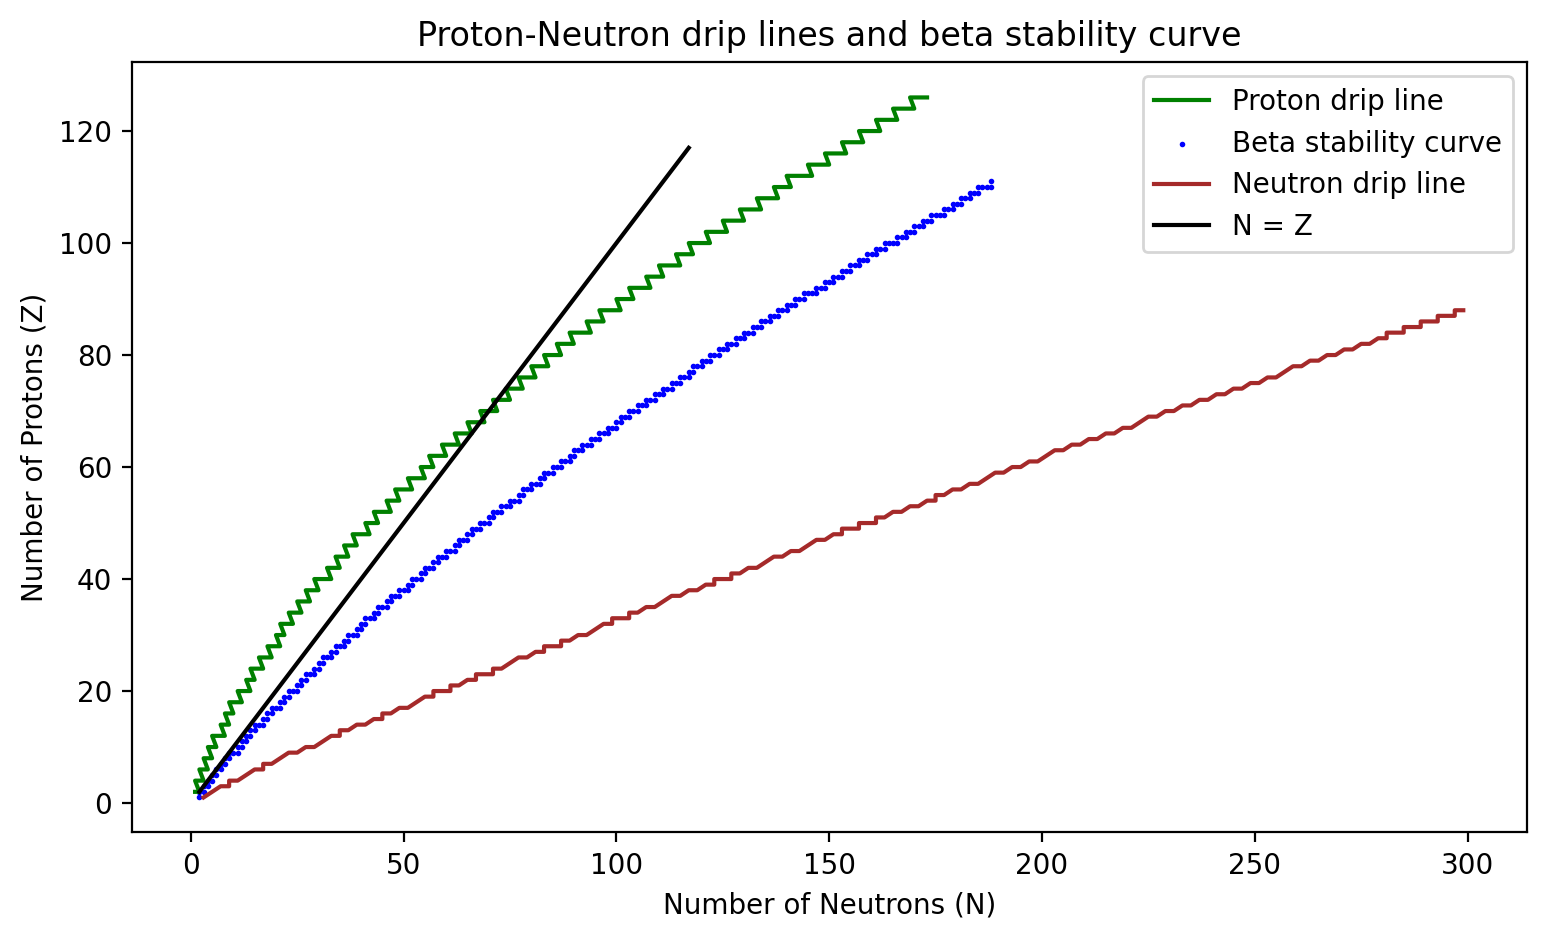

In [ ]:
# Proton-Neutron drip lines and beta stability curve

import numpy as np
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6), dpi=200)

# Initializing the coefficients

a_v = 14.1
a_s = 13.0
a_c = 0.595
a_asym = 19

# Define the binding energy function
def bind_en(A, Z):
    if ((A - Z) % 2) != 0 and (Z % 2) == 0:
        a_p = 0
    elif ((A - Z) % 2) == 0 and (Z % 2) != 0:
        a_p = 0
    elif ((A - Z) % 2) == 0 and (Z % 2) == 0:
        a_p = 33.5
    elif ((A - Z) % 2) != 0 and (Z % 2) != 0:
        a_p = -33.5

    e_v = a_v * A
    e_s = a_s * (A ** (2 / 3))
    e_c = (a_c * Z * (Z - 1)) / (A ** (1 / 3))
    e_asym = a_asym * ((A - 2 * Z) ** 2) / (A * (1 + np.exp(-A / 17)))
    e_p = a_p / (A ** (1 / 2)) * (1 - np.exp(-A / 30))

    b = e_v - e_s - e_c - e_asym + e_p
    return b

# Function to find the minimum Z value
def zmin(A):
    z = (A / 2) * (1 / (1 + 0.25 * (A ** (2 / 3)) * (a_c / a_asym)))
    z = round(z)
    return z

# Generate an array of A values
A = np.arange(3, 300, 1)
Z_stab = []
N_stab = []

# Calculate Z values for the beta stability curve
for a in A:
    z = zmin(a)
    Z_stab.append(z)
    N_stab.append(a - z)

# Function to calculate the separation energy for protons
def sep_p(a, z):
    return bind_en(a, z) - bind_en(a - 1, z - 1)

# Function to calculate the separation energy for neutrons
def sep_n(a, z):
    return bind_en(a, z) - bind_en(a - 1, z)

ndrip_p = []
ndrip_n = []
pdrip_n = []
pdrip_p = []

# Calculate the proton drip line
for a in A:
    n = 1
    while sep_p(a, a - n) < 0:
        n += 1
    pdrip_n.append(n)
    pdrip_p.append(a - n)

# Calculate the neutron drip line
for a in A:
    n = 299
    while sep_n(a, abs(a - n)) > 0:
        n -= 1
    ndrip_p.append(zmin(a))
    ndrip_n.append(n)

Z = np.arange(2, 118, 1)  # for N = Z curve

# Plotting Proton and Neutron drip lines
plt.figure(figsize=(9, 5), dpi=200)
plt.plot(pdrip_n, pdrip_p, 'green', label='Proton drip line')
plt.scatter(N_stab, Z_stab, marker='o', s=1, color='blue', label='Beta stability curve')
plt.plot(ndrip_n[:225], ndrip_p[:225], 'brown', label='Neutron drip line')
plt.plot(Z, Z, label='N = Z', color='black')

# Set labels and title
plt.xlabel('Number of Neutrons (N)')
plt.ylabel('Number of Protons (Z)')
plt.title('Proton-Neutron drip lines and beta stability curve')

# Add legend, grid, and display the plot
plt.legend()
plt.show()


# Shell Model

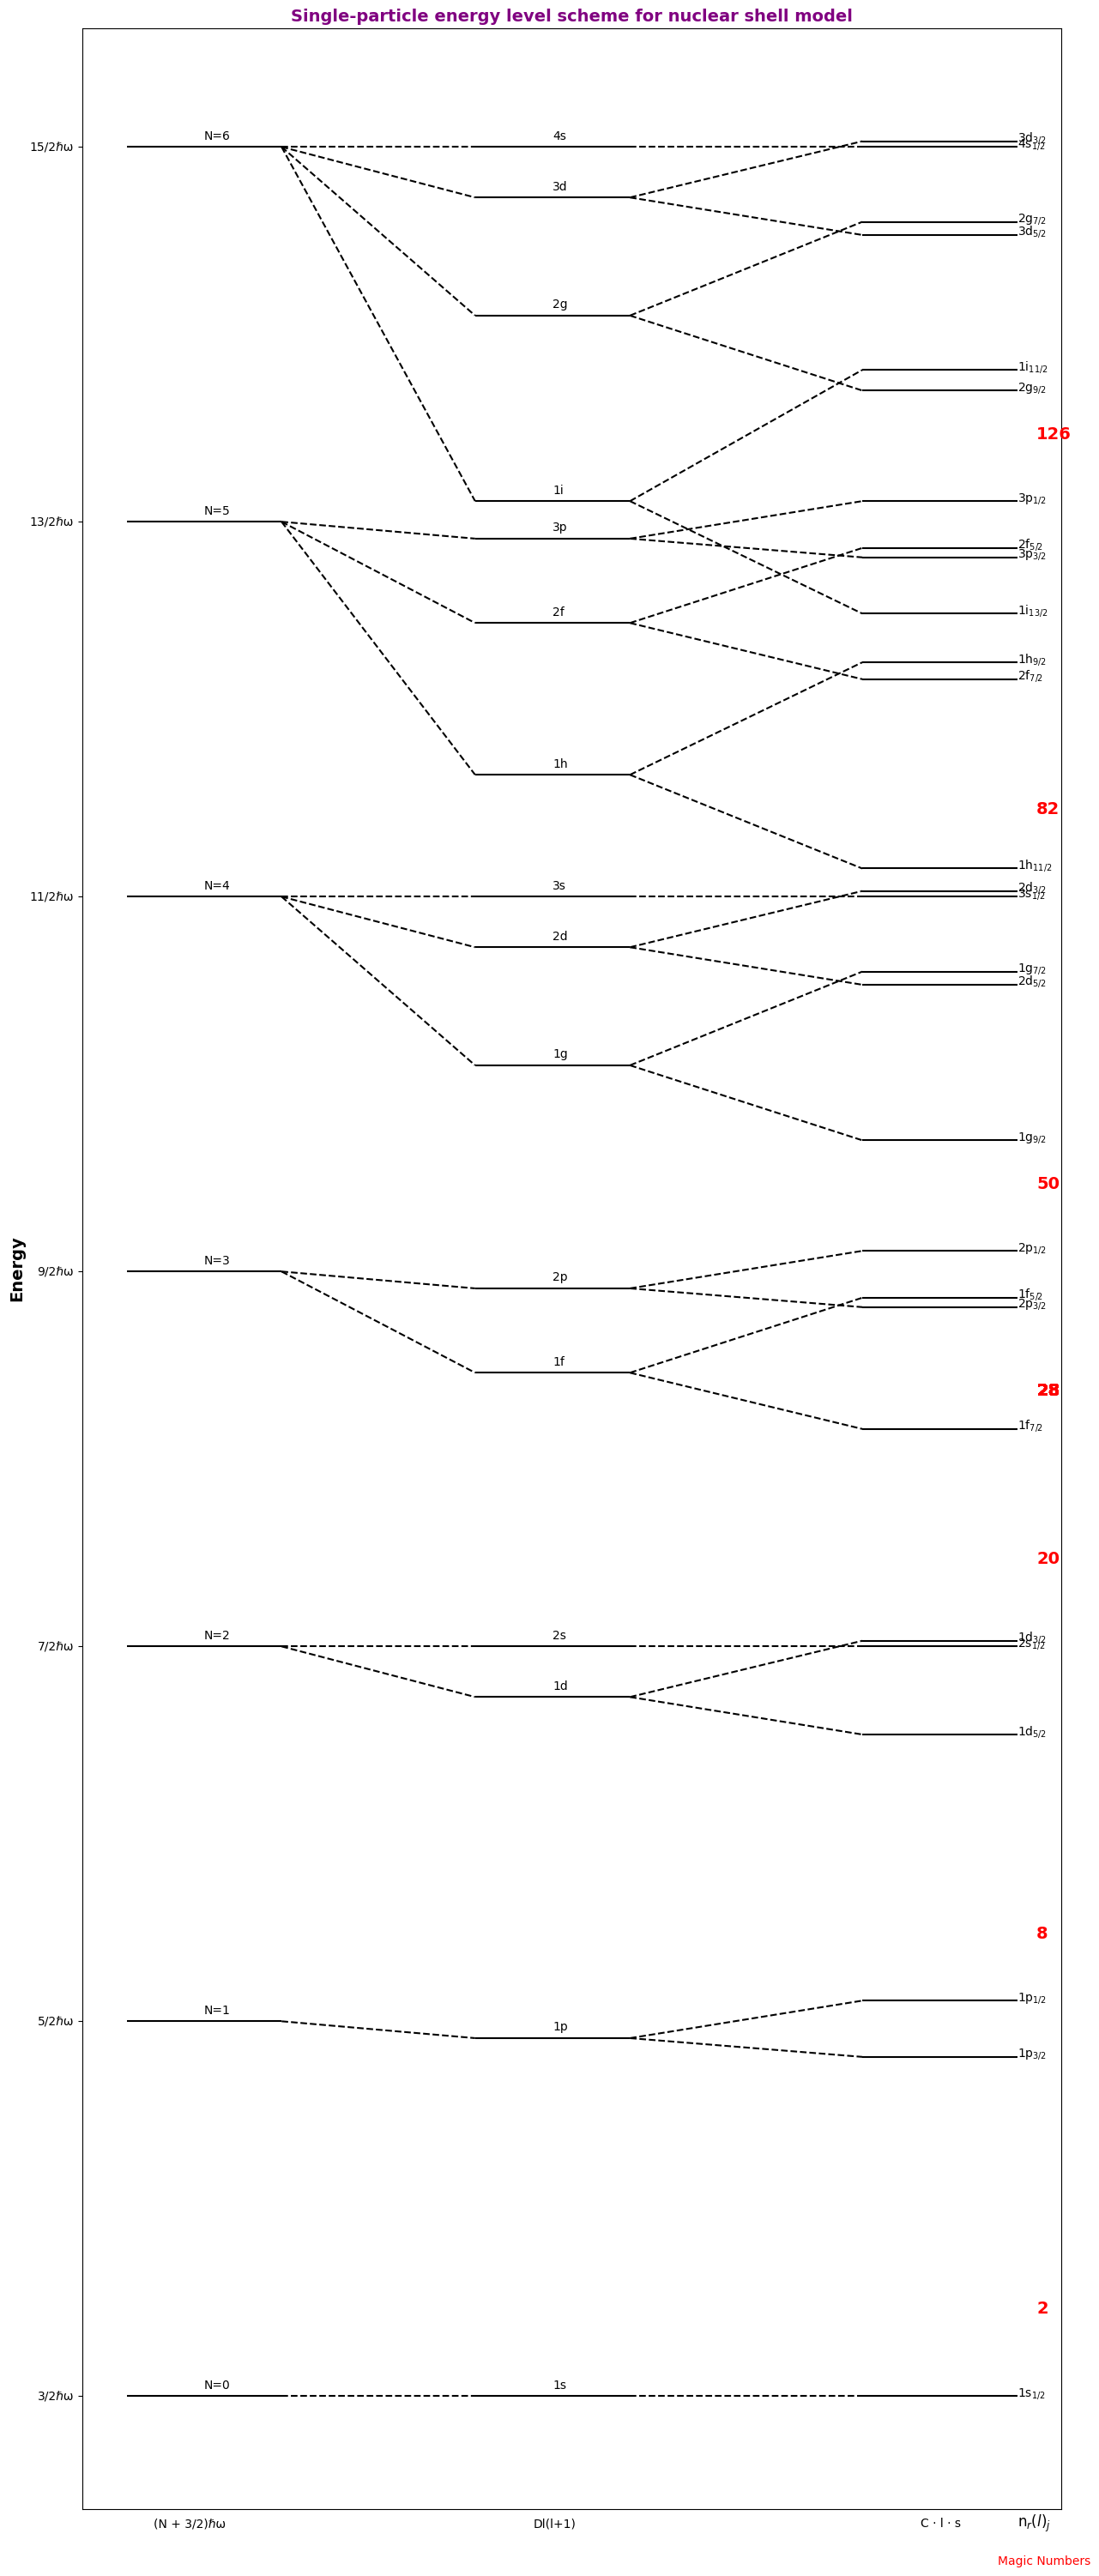

In [ ]:
# Shell Model

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction


magic_number = [2, 8, 20, 50, 82, 126, '']
ℏω = 1
D = -0.0225 * ℏω
C = -0.1 * ℏω
plt.figure(figsize=(13, 30))

def E_h(N):
    h = (N + (3 / 2)) * ℏω
    return h


def E_c(l):
    c = D * l * (l + 1)
    return c


def E_s(l, s):
    if s == (1 / 2):
        so = C * (l / 2)
    if s == (-1 / 2):
        so = C * (-(l + 1) / 2)
    return so


def l_v(N):
    if N % 2 == 0:
        l_value = np.arange(0, N + 1, 2)
    if N % 2 == 1:
        l_value = np.arange(1, N + 1, 2)
    return l_value


def j(l, s):
    ls = abs(int(2 * (l + s)))
    return Fraction(ls, 2)


def n_r(N, l):
    return int((N - l + 2) / 2)

N = 0
while N < 7:
    e_h = E_h(N)
    plt.hlines(e_h, xmin=1.2, xmax=1.6, color='black')
    plt.text(1.4, e_h + 0.02, f'N={N}')
    plt.text(3.55, e_h + 0.22, f'{magic_number[N]}', color='red', fontsize=14, fontweight='bold')


    L = l_v(N)
    l = 0
    while l < len(L):
        e_c = E_h(N) + E_c(L[l])
        plt.plot([1.6, 2.1], [e_h, e_c], linestyle='--', color='black')
        plt.hlines(e_c, xmin=2.1, xmax=2.5, color='black')
        nr = n_r(N, L[l])
        plt.text(2.3, e_c + 0.02, f'{nr}{Lsymb[L[l]]}')

        if L[l] != 0:
            s = 0
            while s < len(S):
                e_s = E_h(N) + E_c(L[l]) + E_s(L[l], S[s])
                plt.hlines(e_s, xmin=3.1, xmax=3.5, color='black')
                jvalue = j(L[l], S[s])
                plt.text(3.5, e_s, f'{nr}{Lsymb[L[l]]}$_{{{jvalue}}}$')
                plt.plot([2.5, 3.1], [e_c, e_s], linestyle='--', color='black')
                s += 1
        elif L[l] == 0:
            s = 1/2
            e_s = E_h(N) + E_c(L[l]) + E_s(L[l], s)
            plt.hlines(e_s, xmin=3.1, xmax=3.5, color='black')
            jvalue = j(L[l], s)
            plt.text(3.5, e_s, f'{nr}{Lsymb[L[l]]}$_{{{jvalue}}}$')
            plt.plot([2.5, 3.1], [e_c, e_s], linestyle='--', color='black')
        l += 1
        plt.text(3.55, E_h(3) + E_c(3) + E_s(3, 1/2) + 0.09, f'{28}', color='red', fontsize=14, fontweight='bold')

    N += 1

y_ticks = [E_h(i) for i in range(7)]
y_tick_labels = [f'{Fraction(y / 1).limit_denominator()}ℏω' for y in y_ticks]
plt.yticks(y_ticks, y_tick_labels)

plt.text(1.27, 1.15, '(N + 3/2)ℏω')
plt.text(2.25, 1.15, 'Dl(l+1)')
plt.text(3.25, 1.15, 'C ⋅ l ⋅ s')
plt.text(3.50, 1.15, 'n$_r$($\mathit{l}$)$_j$', fontsize=12)
plt.text(3.45, 1.05, 'Magic Numbers', color='red')
plt.ylabel('Energy',fontsize=14, fontweight='bold')
plt.gca().axes.get_xaxis().set_visible(False)
plt.title('Single-particle energy level scheme for nuclear shell model', color='purple', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


# Spherical Harmonics

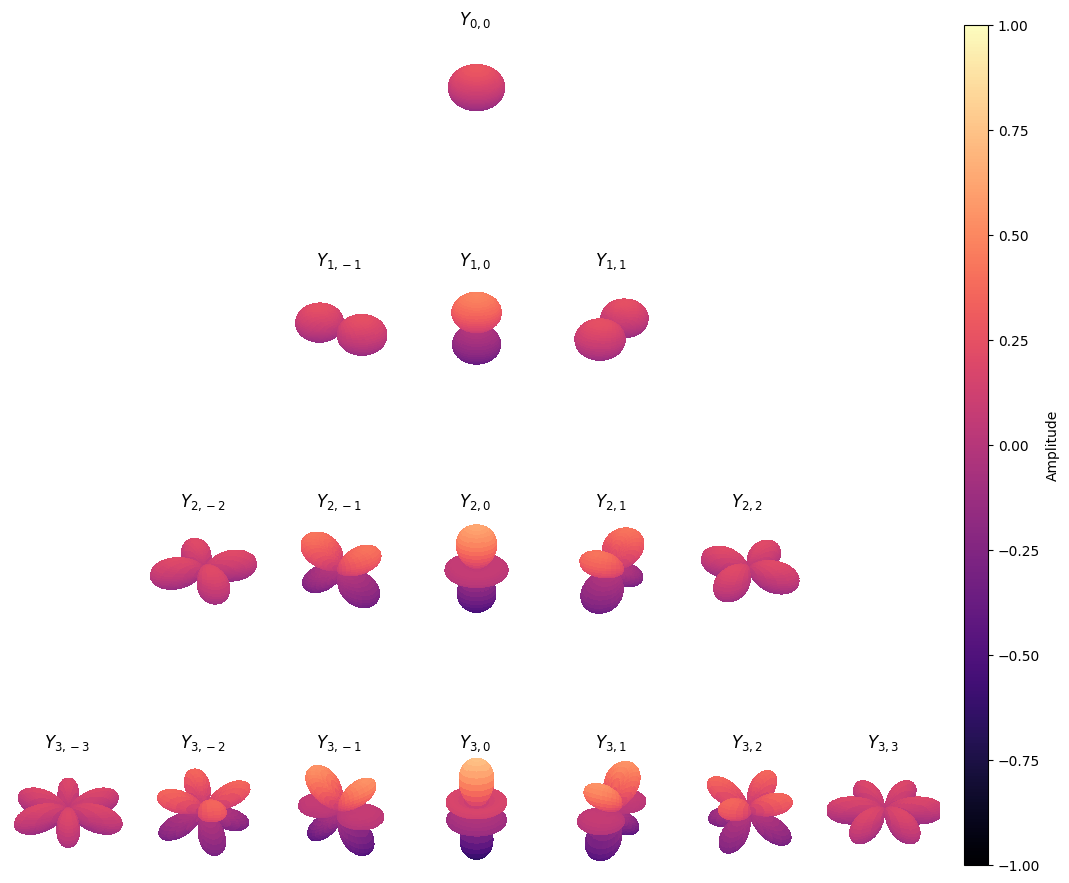

In [ ]:
# Spherical Harmonics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import sph_harm

# Define the angular coordinates
theta_values = np.linspace(0, np.pi, 100)
phi_values = np.linspace(0, 2 * np.pi, 100)
theta, phi = np.meshgrid(theta_values, phi_values)

# Maximum angular momentum quantum number
max_angular_momentum = 3

# Create a figure with subplots for different spherical harmonics
fig = plt.figure(figsize=(12, 12))
spec = gridspec.GridSpec(ncols=2 * max_angular_momentum + 1, nrows=max_angular_momentum + 1, figure=fig)

# Function to plot spherical harmonics
def plot_spherical_harmonic(ax, angular_momentum, magnetic_quantum):
    # Calculate the spherical harmonic function
    spherical_harmonic = sph_harm(abs(magnetic_quantum), angular_momentum, phi, theta)

    # Handling the complex values of the spherical harmonic
    if magnetic_quantum < 0:
        spherical_harmonic = np.sqrt(2) * (-1) ** magnetic_quantum * spherical_harmonic.imag
    elif magnetic_quantum > 0:
        spherical_harmonic = np.sqrt(2) * (-1) ** magnetic_quantum * spherical_harmonic.real

    # Convert spherical coordinates to Cartesian coordinates
    X = np.abs(spherical_harmonic) * np.sin(theta) * np.sin(phi)
    Y = np.abs(spherical_harmonic) * np.sin(theta) * np.cos(phi)
    Z = np.abs(spherical_harmonic) * np.cos(theta)

    # Create a custom colormap for coloring the surface
    colormap = plt.get_cmap('magma')
    norm = plt.Normalize(-1, 1)

    # Plot the spherical harmonic on a 3D surface
    surf = ax.plot_surface(X, Y, Z, cmap=colormap, norm=norm, rstride=2, cstride=2, linewidth=0, antialiased=False)

    # Set the title for the subplot
    ax.set_title(r'$Y_{{{},{}}}$'.format(angular_momentum, magnetic_quantum))

    # Set axis limits and turn off axis labels
    axis_limit = 0.35
    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)
    ax.set_zlim(-axis_limit, axis_limit)
    ax.axis('off')

    return surf  # Return the surf object

# Generate and plot spherical harmonics for different angular_momentum and magnetic_quantum values
for angular_momentum in range(max_angular_momentum + 1):
    for magnetic_quantum in range(-angular_momentum, angular_momentum + 1):
        ax = fig.add_subplot(spec[angular_momentum, magnetic_quantum + max_angular_momentum], projection='3d')
        surf = plot_spherical_harmonic(ax, angular_momentum, magnetic_quantum)

# Create a color bar for reference
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(surf, cax=cbar_ax, orientation='vertical')
cbar.set_label('Amplitude', rotation=90)

# Adjust layout and display the plot
plt.show()
